In [15]:
import pandas as pd
df = pd.read_csv('df_causal_impact_homework.csv')
df

,date,treatment,revenue_total,revenue_outerwear,revenue_shoes,revenue_pants,dau
0,2022-01-01,0,515814.757793,220334.566840,162175.751296,133304.439657,100248
1,2022-01-02,0,515228.472040,220091.525247,165866.886842,129270.059952,99949
2,2022-01-03,0,516414.464703,216796.098161,169626.697165,129991.669376,100360
3,2022-01-04,0,516826.380111,223573.379145,163554.756119,129698.244848,100816
4,2022-01-05,0,515471.875206,220747.894420,165388.027376,129335.953410,99955
...,...,...,...,...,...,...,...
1090,2024-12-26,1,530374.020277,226575.625191,171449.316446,132349.078639,100844
1091,2024-12-27,1,520376.250725,220748.996381,173290.776071,126336.478274,100870
1092,2024-12-28,1,529037.911435,223881.799700,169531.456936,135624.654799,101261
1093,2024-12-29,1,529772.586003,222932.839783,175113.161526,131726.584695,100931


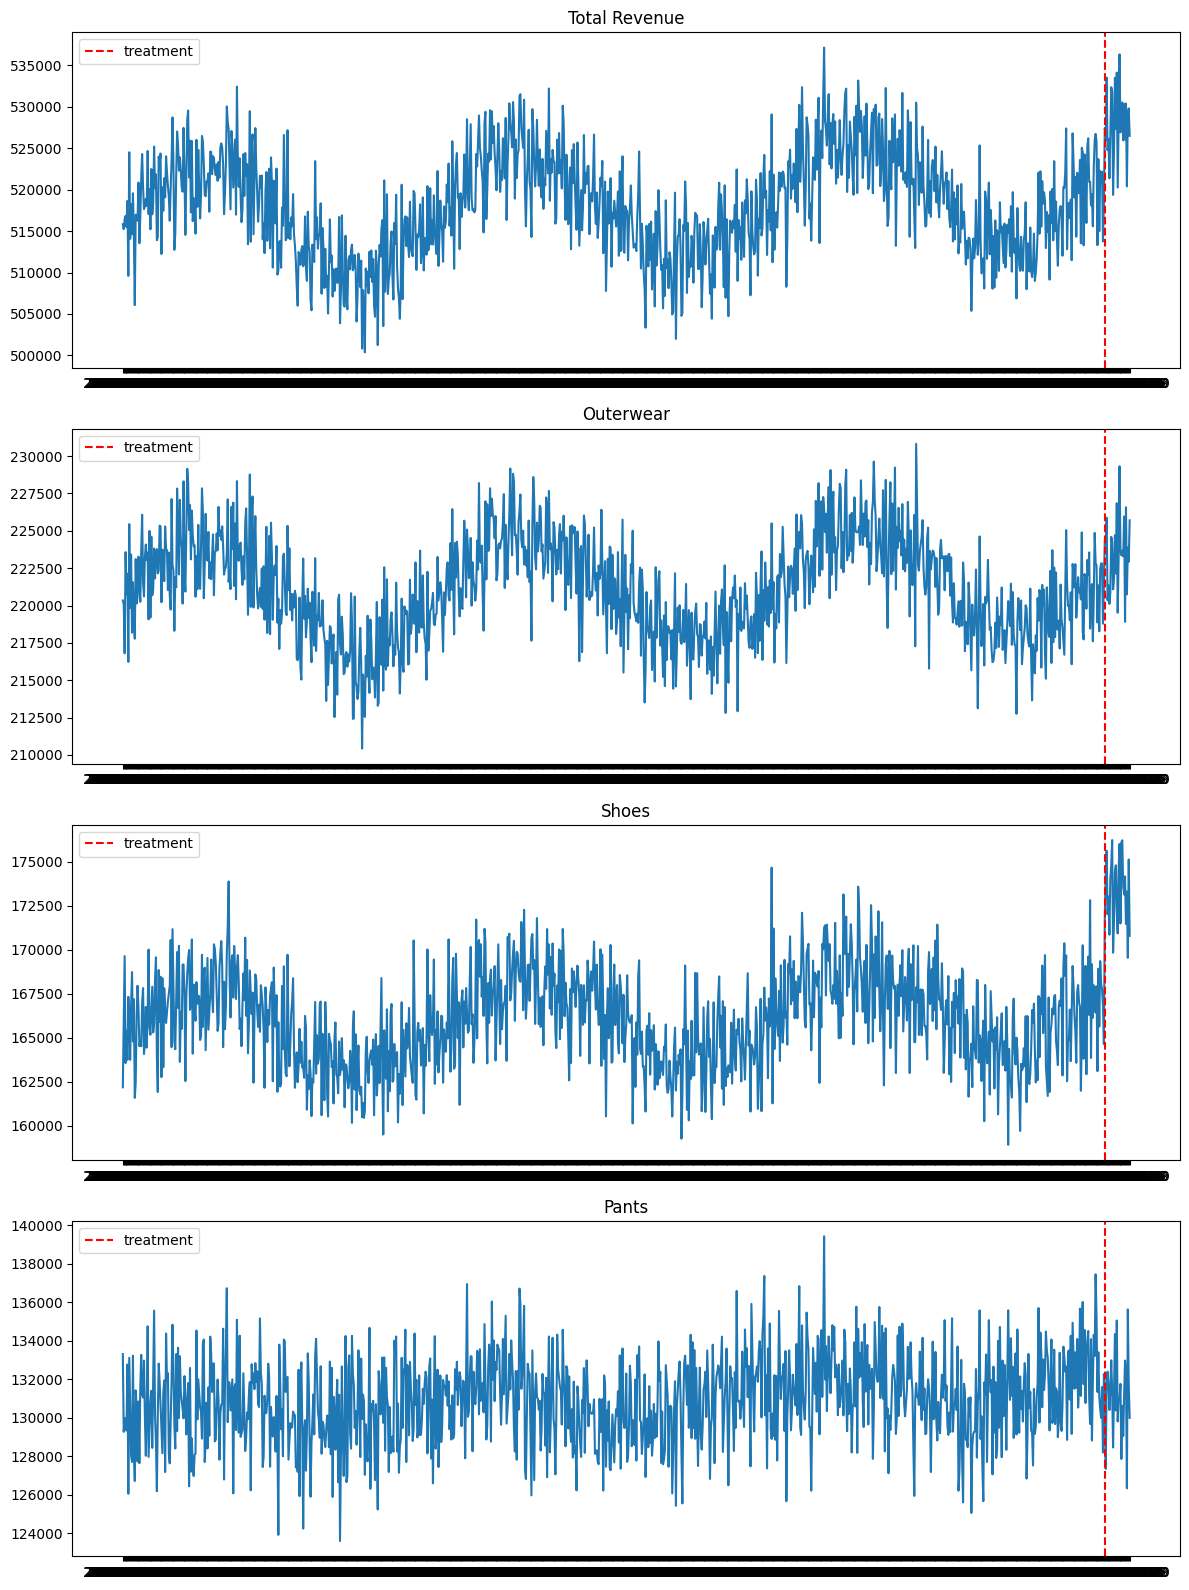

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

cols = ['revenue_total', 'revenue_outerwear', 'revenue_shoes', 'revenue_pants']
titles = ['Total Revenue', 'Outerwear', 'Shoes', 'Pants']

for i, (col, title) in enumerate(zip(cols, titles)):
    axes[i].plot(df['date'], df[col])
    axes[i].axvline(x=df[df['treatment']==1]['date'].iloc[0], color='red', linestyle='--', label='treatment')
    axes[i].set_title(title)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [17]:
cols = ['revenue_total', 'revenue_outerwear', 'revenue_shoes', 'revenue_pants', 'dau']

# Только предпериод (treatment == 0)
df_pre = df[df['treatment'] == 0]

corr_matrix = df_pre[cols].corr()
print(corr_matrix.round(3))

                   revenue_total  revenue_outerwear  revenue_shoes  \
revenue_total              1.000              0.847          0.776   
revenue_outerwear          0.847              1.000          0.519   
revenue_shoes              0.776              0.519          1.000   
revenue_pants              0.542              0.197          0.157   
dau                        0.786              0.742          0.612   

                   revenue_pants    dau  
revenue_total              0.542  0.786  
revenue_outerwear          0.197  0.742  
revenue_shoes              0.157  0.612  
revenue_pants              1.000  0.308  
dau                        0.308  1.000  


In [18]:
post_length = df[df['treatment'] == 1].shape[0]
print('Длина post-периода:', post_length)

Длина post-периода: 28


In [19]:
cols = ['revenue_total', 'revenue_shoes', 'revenue_pants', 'revenue_outerwear']

best_lags = {}

for col in cols:
    best_corr = 0
    best_lag = 28
    
    for lag in range(28, 90):
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
        # только строки где лаг не пустой
        df_valid = df[[col, f'{col}_lag_{lag}']].dropna()
        corr = df_valid[col].corr(df_valid[f'{col}_lag_{lag}'])
        
        if corr > best_corr:
            best_corr = corr
            best_lag = lag
    
    best_lags[col] = (best_lag, best_corr)
    # создаём ковариату с оптимальным лагом
    df[f'{col}_lag'] = df[col].shift(best_lag)
    print(f'{col}: лаг={best_lag}, корреляция={round(best_corr, 2)}')

# Корреляция для revenue_pants
pants_lag = best_lags['revenue_pants'][0]
df_valid = df[['revenue_pants', f'revenue_pants_lag_{pants_lag}']].dropna()
corr_pants = df_valid['revenue_pants'].corr(df_valid[f'revenue_pants_lag_{pants_lag}'])
print(f'\nКорреляция revenue_pants с лагом {pants_lag}:', round(corr_pants, 2))

revenue_total: лаг=30, корреляция=0.49
revenue_shoes: лаг=29, корреляция=0.35
revenue_pants: лаг=32, корреляция=0.12
revenue_outerwear: лаг=29, корреляция=0.5

Корреляция revenue_pants с лагом 32: 0.12


/var/folders/6r/hytlw2sn1fs_9jzjy_lsxtg80000gn/T/ipykernel_5689/2871258523.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{lag}'] = df[col].shift(lag)
/var/folders/6r/hytlw2sn1fs_9jzjy_lsxtg80000gn/T/ipykernel_5689/2871258523.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_{lag}'] = df[col].shift(lag)
/var/folders/6r/hytlw2sn1fs_9jzjy_lsxtg80000gn/T/ipykernel_5689/2871258523.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

In [20]:
from causalimpact import CausalImpact
import pandas as pd

# Убираем строки где лаг пустой, сохраняем treatment отдельно
df_temp = df[['date', 'treatment', 'revenue_shoes', 'dau', 'revenue_shoes_lag']].dropna().reset_index(drop=True)

# Индексы периодов
pre_end = df_temp[df_temp['treatment'] == 0].index[-1]
post_start = df_temp[df_temp['treatment'] == 1].index[0]
post_end = df_temp[df_temp['treatment'] == 1].index[-1]

pre_period = [0, pre_end]
post_period = [post_start, post_end]

print(f'Pre: {pre_period}, Post: {post_period}')

# Данные для CI — индекс должен быть датой
df_ci = df_temp[['revenue_shoes', 'dau', 'revenue_shoes_lag']].copy()
df_ci.index = pd.to_datetime(df_temp['date'])

# Периоды тоже датами
pre_period = [df_ci.index[0], df_ci.index[pre_end]]
post_period = [df_ci.index[post_start], df_ci.index[post_end]]

print(f'Pre: {pre_period}')
print(f'Post: {post_period}')

ci = CausalImpact(df_ci, pre_period, post_period)
ci

Pre: [0, 1037], Post: [1038, 1065]
Pre: [Timestamp('2022-01-30 00:00:00'), Timestamp('2024-12-02 00:00:00')]
Post: [Timestamp('2024-12-03 00:00:00'), Timestamp('2024-12-30 00:00:00')]


In [21]:
print(ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    173280.77          4851861.5
Prediction (s.d.)         167816.7 (506.42)  4698867.5 (14179.77)
95% CI                    [166824.02, 168809.16][4671072.61, 4726656.31]

Absolute effect (s.d.)    5464.06 (506.42)   152994.0 (14179.77)
95% CI                    [4471.61, 6456.75] [125205.19, 180788.89]

Relative effect (s.d.)    3.26% (0.3%)       3.26% (0.3%)
95% CI                    [2.66%, 3.85%]     [2.66%, 3.85%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [22]:
# Пересоздаём с нуля
df_temp = df[['date', 'treatment', 'revenue_shoes', 'dau']].copy()

# Оптимальный лаг для revenue_shoes из best_lags
shoes_lag = best_lags['revenue_shoes'][0]
print(f'Используем лаг: {shoes_lag}')

df_temp['revenue_shoes_lag'] = df['revenue_shoes'].shift(shoes_lag)
df_temp = df_temp.dropna(subset=['revenue_shoes_lag']).reset_index(drop=True)

print(df_temp.shape)
print(df_temp['treatment'].value_counts())

Используем лаг: 29
(1066, 5)
treatment
0    1038
1      28
Name: count, dtype: int64


In [23]:
df_ci = df_temp[['revenue_shoes', 'dau', 'revenue_shoes_lag']].copy()
df_ci.index = pd.to_datetime(df_temp['date'])

pre_period = [df_ci.index[0], df_ci.index[1037]]
post_period = [df_ci.index[1038], df_ci.index[1065]]

print(pre_period)
print(post_period)

ci = CausalImpact(df_ci, pre_period, post_period)
print(ci.summary())

[Timestamp('2022-01-30 00:00:00'), Timestamp('2024-12-02 00:00:00')]
[Timestamp('2024-12-03 00:00:00'), Timestamp('2024-12-30 00:00:00')]
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    173280.77          4851861.5
Prediction (s.d.)         167700.55 (522.33) 4695615.5 (14625.13)
95% CI                    [166714.05, 168761.54][4667993.41, 4725322.88]

Absolute effect (s.d.)    5580.22 (522.33)   156246.0 (14625.13)
95% CI                    [4519.23, 6566.71] [126538.62, 183868.09]

Relative effect (s.d.)    3.33% (0.31%)      3.33% (0.31%)
95% CI                    [2.69%, 3.92%]     [2.69%, 3.92%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from causalimpact import CausalImpact

# Загрузка данных
df = pd.read_csv('df_causal_impact_homework.csv')
df['date'] = pd.to_datetime(df['date'])
print(df.head())
print(df.shape)

        date  treatment  revenue_total  revenue_outerwear  revenue_shoes  \
0 2022-01-01          0  515814.757793      220334.566840  162175.751296   
1 2022-01-02          0  515228.472040      220091.525247  165866.886842   
2 2022-01-03          0  516414.464703      216796.098161  169626.697165   
3 2022-01-04          0  516826.380111      223573.379145  163554.756119   
4 2022-01-05          0  515471.875206      220747.894420  165388.027376   

   revenue_pants     dau  
0  133304.439657  100248  
1  129270.059952   99949  
2  129991.669376  100360  
3  129698.244848  100816  
4  129335.953410   99955  
(1095, 7)


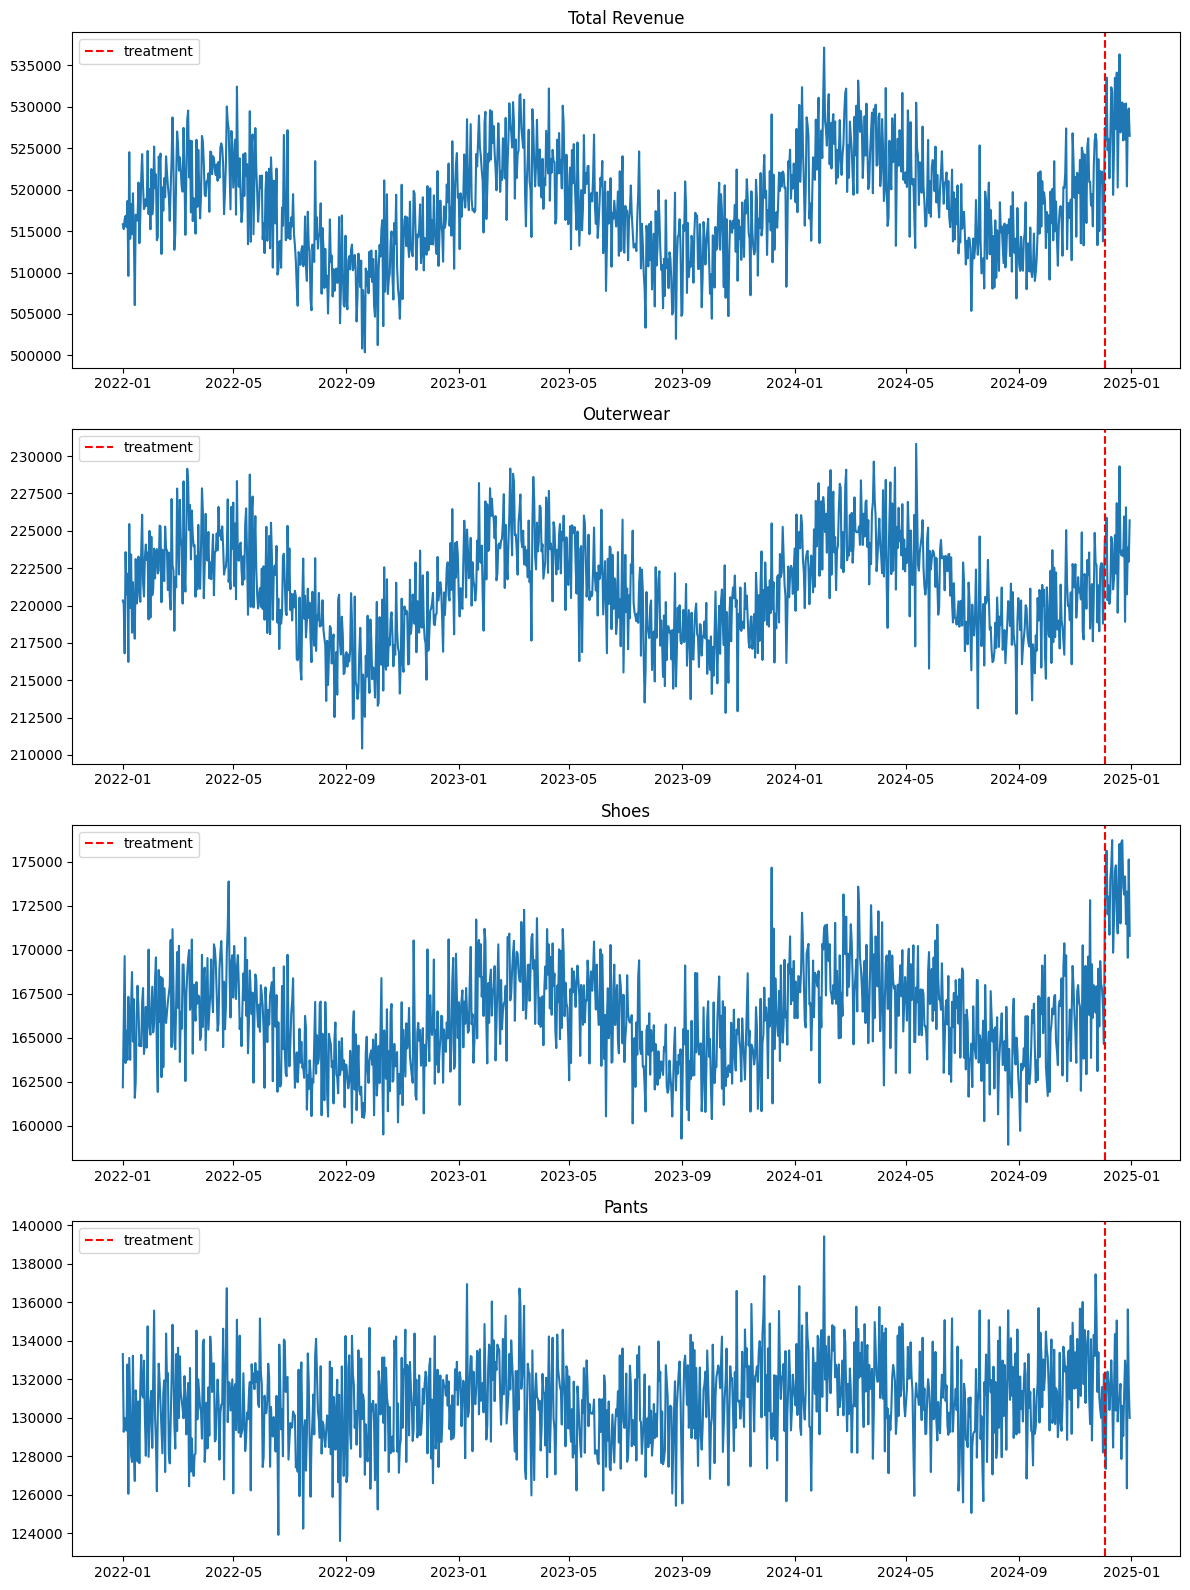

In [25]:
# Визуализация выручки
fig, axes = plt.subplots(4, 1, figsize=(12, 16))
cols = ['revenue_total', 'revenue_outerwear', 'revenue_shoes', 'revenue_pants']
titles = ['Total Revenue', 'Outerwear', 'Shoes', 'Pants']

for i, (col, title) in enumerate(zip(cols, titles)):
    axes[i].plot(df['date'], df[col])
    axes[i].axvline(x=df[df['treatment']==1]['date'].iloc[0], color='red', linestyle='--', label='treatment')
    axes[i].set_title(title)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [26]:
# Корреляция Пирсона в pre-периоде
cols = ['revenue_total', 'revenue_outerwear', 'revenue_shoes', 'revenue_pants', 'dau']
df_pre = df[df['treatment'] == 0]
corr_matrix = df_pre[cols].corr()
print(corr_matrix.round(3))

                   revenue_total  revenue_outerwear  revenue_shoes  \
revenue_total              1.000              0.847          0.776   
revenue_outerwear          0.847              1.000          0.519   
revenue_shoes              0.776              0.519          1.000   
revenue_pants              0.542              0.197          0.157   
dau                        0.786              0.742          0.612   

                   revenue_pants    dau  
revenue_total              0.542  0.786  
revenue_outerwear          0.197  0.742  
revenue_shoes              0.157  0.612  
revenue_pants              1.000  0.308  
dau                        0.308  1.000  


In [27]:
# Длина post-периода
post_length = df[df['treatment'] == 1].shape[0]
print('Длина post-периода:', post_length)

Длина post-периода: 28


In [28]:
# Подбор оптимального лага для каждой переменной
cols = ['revenue_total', 'revenue_shoes', 'revenue_pants', 'revenue_outerwear']
best_lags = {}

for col in cols:
    best_corr = 0
    best_lag = 28
    for lag in range(28, 90):
        lagged = df[col].shift(lag)
        df_valid = pd.concat([df[col], lagged], axis=1).dropna()
        df_valid.columns = ['original', 'lagged']
        corr = df_valid['original'].corr(df_valid['lagged'])
        if corr > best_corr:
            best_corr = corr
            best_lag = lag
    best_lags[col] = (best_lag, round(best_corr, 2))
    print(f'{col}: лаг={best_lag}, корреляция={round(best_corr, 2)}')

print(best_lags)

revenue_total: лаг=30, корреляция=0.49
revenue_shoes: лаг=29, корреляция=0.35
revenue_pants: лаг=32, корреляция=0.12
revenue_outerwear: лаг=29, корреляция=0.5
{'revenue_total': (30, 0.49), 'revenue_shoes': (29, 0.35), 'revenue_pants': (32, 0.12), 'revenue_outerwear': (29, 0.5)}


(1066, 5)
treatment
0    1038
1      28
Name: count, dtype: int64
Pre: [Timestamp('2022-01-30 00:00:00'), Timestamp('2024-12-02 00:00:00')]
Post: [Timestamp('2024-12-03 00:00:00'), Timestamp('2024-12-30 00:00:00')]
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    173280.77          4851861.5
Prediction (s.d.)         168027.48 (534.14) 4704769.5 (14955.94)
95% CI                    [166973.2, 169066.99][4675249.76, 4733875.97]

Absolute effect (s.d.)    5253.28 (534.14)   147092.0 (14955.94)
95% CI                    [4213.77, 6307.56] [117985.53, 176611.74]

Relative effect (s.d.)    3.13% (0.32%)      3.13% (0.32%)
95% CI                    [2.51%, 3.75%]     [2.51%, 3.75%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


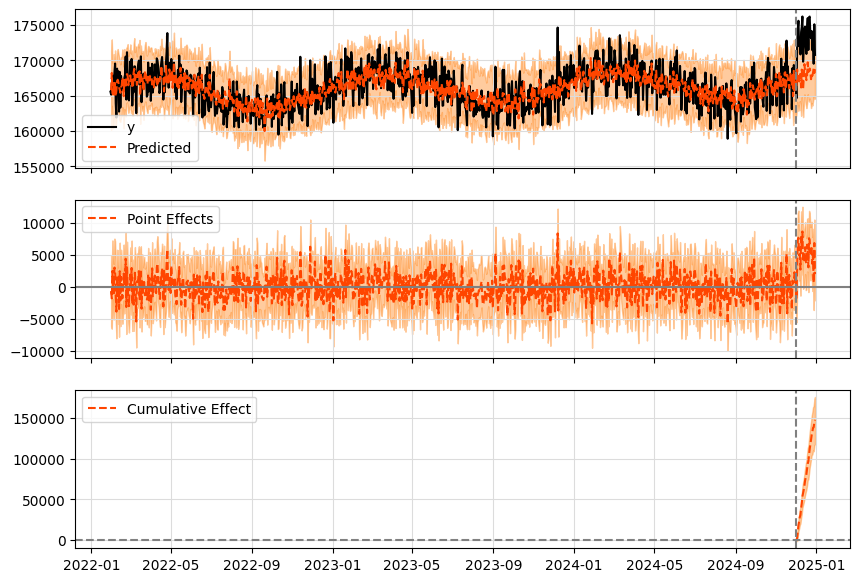

In [29]:
# Causal Impact для revenue_shoes
shoes_lag = best_lags['revenue_shoes'][0]

df_temp = df[['date', 'treatment', 'revenue_shoes', 'dau']].copy()
df_temp['revenue_shoes_lag'] = df['revenue_shoes'].shift(shoes_lag)
df_temp = df_temp.dropna(subset=['revenue_shoes_lag']).reset_index(drop=True)

print(df_temp.shape)
print(df_temp['treatment'].value_counts())

df_ci = df_temp[['revenue_shoes', 'dau', 'revenue_shoes_lag']].copy()
df_ci.index = pd.to_datetime(df_temp['date'])

pre_period = [df_ci.index[0], df_ci.index[df_temp[df_temp['treatment']==0].index[-1]]]
post_period = [df_ci.index[df_temp[df_temp['treatment']==1].index[0]], df_ci.index[-1]]

print('Pre:', pre_period)
print('Post:', post_period)

ci = CausalImpact(df_ci, pre_period, post_period)
print(ci.summary())
ci.plot()

Используем лаг: 32
(1063, 5)
treatment
0    1035
1      28
Name: count, dtype: int64
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    131127.98          3671583.5
Prediction (s.d.)         132774.23 (509.73) 3717678.75 (14272.49)
95% CI                    [131842.48, 133840.58][3691589.41, 3747536.55]

Absolute effect (s.d.)    -1646.25 (509.73)  -46095.25 (14272.49)
95% CI                    [-2712.6, -714.5]  [-75953.05, -20005.91]

Relative effect (s.d.)    -1.24% (0.38%)     -1.24% (0.38%)
95% CI                    [-2.04%, -0.54%]   [-2.04%, -0.54%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


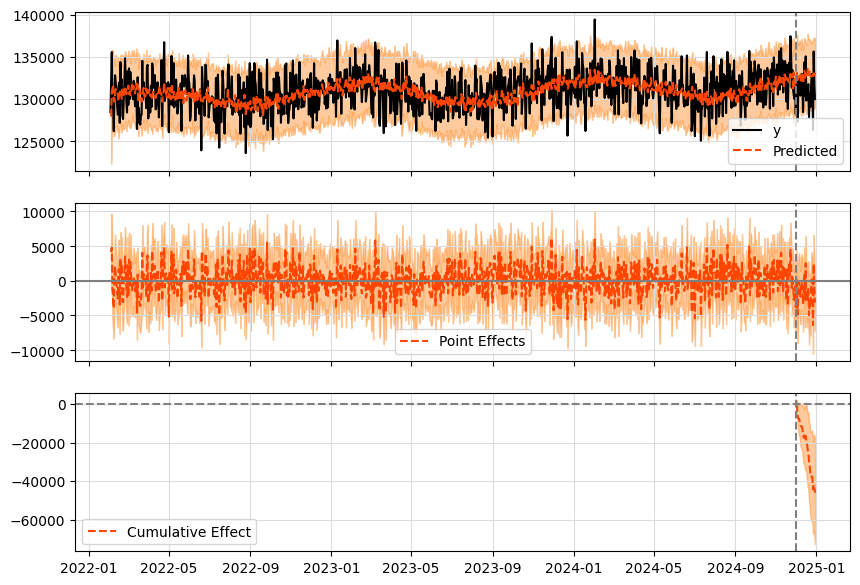

In [30]:
pants_lag = best_lags['revenue_pants'][0]
print(f'Используем лаг: {pants_lag}')

df_temp2 = df[['date', 'treatment', 'revenue_pants', 'dau']].copy()
df_temp2['revenue_pants_lag'] = df['revenue_pants'].shift(pants_lag)
df_temp2 = df_temp2.dropna(subset=['revenue_pants_lag']).reset_index(drop=True)

print(df_temp2.shape)
print(df_temp2['treatment'].value_counts())

df_ci2 = df_temp2[['revenue_pants', 'dau', 'revenue_pants_lag']].copy()
df_ci2.index = pd.to_datetime(df_temp2['date'])

pre_period2 = [df_ci2.index[0], df_ci2.index[df_temp2[df_temp2['treatment']==0].index[-1]]]
post_period2 = [df_ci2.index[df_temp2[df_temp2['treatment']==1].index[0]], df_ci2.index[-1]]

ci2 = CausalImpact(df_ci2, pre_period2, post_period2)
print(ci2.summary())
ci2.plot()

Используем лаг: 29
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    223326.05          6253129.5
Prediction (s.d.)         222594.42 (570.5)  6232644.0 (15974.03)
95% CI                    [221455.03, 223691.35][6200740.62, 6263357.7]

Absolute effect (s.d.)    731.62 (570.5)     20485.5 (15974.03)
95% CI                    [-365.31, 1871.02] [-10228.2, 52388.88]

Relative effect (s.d.)    0.33% (0.26%)      0.33% (0.26%)
95% CI                    [-0.16%, 0.84%]    [-0.16%, 0.84%]

Posterior tail-area probability p: 0.12
Posterior prob. of a causal effect: 87.71%

For more details run the command: print(impact.summary('report'))


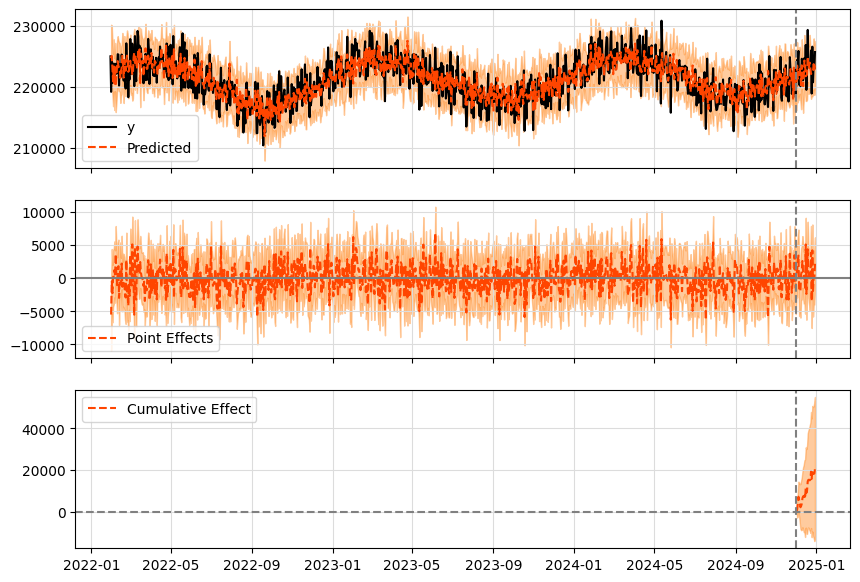

In [31]:
# Causal Impact для revenue_outerwear
outerwear_lag = best_lags['revenue_outerwear'][0]
print(f'Используем лаг: {outerwear_lag}')

df_temp3 = df[['date', 'treatment', 'revenue_outerwear', 'dau']].copy()
df_temp3['revenue_outerwear_lag'] = df['revenue_outerwear'].shift(outerwear_lag)
df_temp3 = df_temp3.dropna(subset=['revenue_outerwear_lag']).reset_index(drop=True)

df_ci3 = df_temp3[['revenue_outerwear', 'dau', 'revenue_outerwear_lag']].copy()
df_ci3.index = pd.to_datetime(df_temp3['date'])

pre_period3 = [df_ci3.index[0], df_ci3.index[df_temp3[df_temp3['treatment']==0].index[-1]]]
post_period3 = [df_ci3.index[df_temp3[df_temp3['treatment']==1].index[0]], df_ci3.index[-1]]

ci3 = CausalImpact(df_ci3, pre_period3, post_period3)
print(ci3.summary())
ci3.plot()

Используем лаг: 30
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    527734.81          14776574.0
Prediction (s.d.)         523539.75 (974.46) 14659113.0 (27284.97)
95% CI                    [521642.89, 525462.7][14606000.97, 14712956.12]

Absolute effect (s.d.)    4195.06 (974.46)   117461.0 (27284.97)
95% CI                    [2272.11, 6091.92] [63617.88, 170573.03]

Relative effect (s.d.)    0.8% (0.19%)       0.8% (0.19%)
95% CI                    [0.43%, 1.16%]     [0.43%, 1.16%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


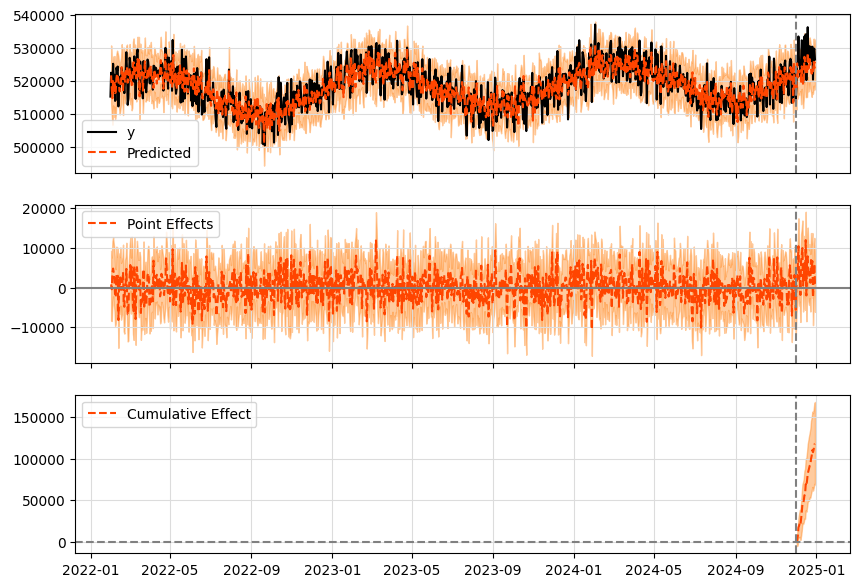

In [32]:
total_lag = best_lags['revenue_total'][0]
print(f'Используем лаг: {total_lag}')

df_temp4 = df[['date', 'treatment', 'revenue_total', 'dau']].copy()
df_temp4['revenue_total_lag'] = df['revenue_total'].shift(total_lag)
df_temp4 = df_temp4.dropna(subset=['revenue_total_lag']).reset_index(drop=True)

df_ci4 = df_temp4[['revenue_total', 'dau', 'revenue_total_lag']].copy()
df_ci4.index = pd.to_datetime(df_temp4['date'])

pre_period4 = [df_ci4.index[0], df_ci4.index[df_temp4[df_temp4['treatment']==0].index[-1]]]
post_period4 = [df_ci4.index[df_temp4[df_temp4['treatment']==1].index[0]], df_ci4.index[-1]]

ci4 = CausalImpact(df_ci4, pre_period4, post_period4)
print(ci4.summary())
ci4.plot()

In [33]:
print(ci4.inferences.columns)
print(ci4.inferences.head())

Index(['complete_preds_means', 'complete_preds_lower', 'complete_preds_upper',
       'post_preds_means', 'post_preds_lower', 'post_preds_upper',
       'post_cum_y', 'post_cum_preds_means', 'post_cum_preds_lower',
       'post_cum_preds_upper', 'point_effects_means', 'point_effects_lower',
       'point_effects_upper', 'post_cum_effects_means',
       'post_cum_effects_lower', 'post_cum_effects_upper'],
      dtype='object')
            complete_preds_means  complete_preds_lower  complete_preds_upper  \
date                                                                           
2022-01-31          515998.87500         496571.432812         534305.178125   
2022-02-01          521666.56250         513228.182812         530748.681250   
2022-02-02          517428.37500         509421.979687         525409.435937   
2022-02-03          514720.03125         506673.586719         522256.973438   
2022-02-04          520396.18750         512534.082813         527392.267188   

         

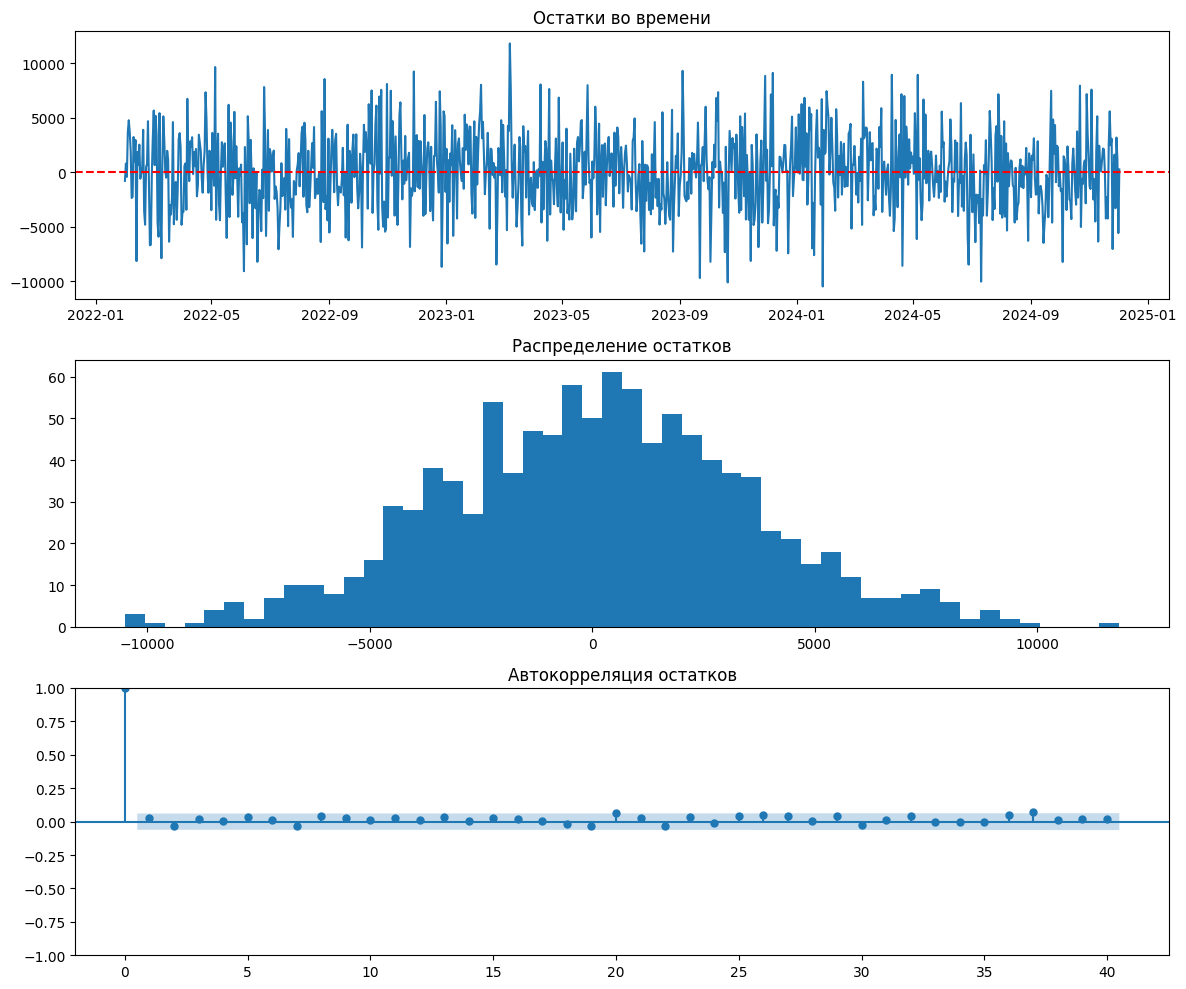

     lb_stat  lb_pvalue
1   0.892802   0.344719
2   2.174688   0.337111
3   2.675955   0.444329
4   2.683050   0.612184
5   3.719822   0.590417
6   3.896114   0.690733
7   5.214772   0.633772
8   7.344942   0.499914
9   7.980641   0.536098
10  8.065903   0.622400

Среднее остатков: 78.22
p-value (среднее = 0): 0.4698


In [34]:
# Остатки = факт - предсказание в pre-периоде
residuals = (df_ci4['revenue_total'] - ci4.inferences['complete_preds_means']).loc[pre_period4[0]:pre_period4[1]].dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Остатки во времени
axes[0].plot(residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Остатки во времени')

# Гистограмма
axes[1].hist(residuals, bins=50)
axes[1].set_title('Распределение остатков')

# ACF
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=40, ax=axes[2])
axes[2].set_title('Автокорреляция остатков')

plt.tight_layout()
plt.show()

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print(lb_test)

# Среднее остатков
from scipy import stats
t_stat, p_value = stats.ttest_1samp(residuals, 0)
print(f'\nСреднее остатков: {residuals.mean():.2f}')
print(f'p-value (среднее = 0): {p_value:.4f}')

In [35]:
lag_col = f'revenue_total_lag_{best_lags["revenue_total"][0]}'

# Создаём все преобразования
transforms = {
    'исходная': df[lag_col],
    'rolling_7_mean': df[lag_col].rolling(7, min_periods=1).mean(),
    'rolling_10_mean': df[lag_col].rolling(10, min_periods=1).mean(),
    'rolling_14_mean': df[lag_col].rolling(14, min_periods=1).mean(),
    'ewm_5': df[lag_col].ewm(span=5).mean(),
    'ewm_14': df[lag_col].ewm(span=14).mean(),
    'rolling_7_std': df[lag_col].rolling(7, min_periods=1).std(),
    'rank_pct': df[lag_col].rank(pct=True),
}

# Считаем корреляцию с revenue_total только где нет NaN
results = {}
for name, series in transforms.items():
    valid = pd.concat([df['revenue_total'], series], axis=1).dropna()
    corr = valid.iloc[:, 0].corr(valid.iloc[:, 1])
    results[name] = round(corr, 4)

# Сортируем по убыванию
results_sorted = sorted(results.items(), key=lambda x: x[1], reverse=True)
for name, corr in results_sorted:
    print(f'{name}: {corr}')

KeyError: 'revenue_total_lag_30'

In [ ]:
from importlib import reload
import causalimpact
reload(causalimpact)
from causalimpact import CausalImpact

# Новые ковариаты — rolling_7_mean лага
total_lag = best_lags['revenue_total'][0]
df[f'revenue_total_lag_{total_lag}_rolling7'] = df[f'revenue_total_lag_{total_lag}'].rolling(7, min_periods=1).mean()

# Pre-период с новыми ковариатами
df_temp_new = df[['date', 'treatment', 'revenue_total', 'dau', 
                   f'revenue_total_lag_{total_lag}_rolling7']].copy()
df_temp_new = df_temp_new[df_temp_new['treatment']==0].reset_index(drop=True)
df_temp_new.index = pd.to_datetime(df_temp_new['date'])

df_pre_new = df_temp_new[['revenue_total', 'dau', f'revenue_total_lag_{total_lag}_rolling7']]

n_pre = len(df_pre_new)
min_train = int(n_pre * 0.5)
post_len = 28
n_simulations = 100
alpha = 0.05
effect_size = 0.01

aa_new = 0
ab_new = 0

for i in range(n_simulations):
    start_idx = np.random.randint(min_train, n_pre - post_len)
    end_idx = start_idx + post_len - 1
    
    pre_sim = [df_pre_new.index[0], df_pre_new.index[start_idx - 1]]
    post_sim = [df_pre_new.index[start_idx], df_pre_new.index[end_idx]]
    
    # A/A
    try:
        ci_aa = CausalImpact(df_pre_new, pre_sim, post_sim,
                             model_args={'prior_level_sd': 0.1})
        if ci_aa.p_value < alpha:
            aa_new += 1
    except:
        pass
    
    # A/B
    try:
        df_ab = df_pre_new.copy()
        df_ab.iloc[start_idx:end_idx+1, 0] *= (1 + effect_size)
        ci_ab = CausalImpact(df_ab, pre_sim, post_sim,
                             model_args={'prior_level_sd': 0.1})
        if ci_ab.p_value < alpha:
            ab_new += 1
    except:
        pass
    
    if (i+1) % 10 == 0:
        print(f'Итерация {i+1}/100')

print(f'FPR новый: {aa_new/n_simulations:.3f}')
print(f'TPR новый: {ab_new/n_simulations:.3f}')

Итерация 10/100
Итерация 20/100
Итерация 30/100
Итерация 40/100
Итерация 50/100
Итерация 60/100
Итерация 70/100
Итерация 80/100
Итерация 90/100
Итерация 100/100
FPR новый: 0.000
TPR новый: 0.000


/var/folders/6r/hytlw2sn1fs_9jzjy_lsxtg80000gn/T/ipykernel_5689/632996499.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'revenue_total_lag_{total_lag}_rolling7'] = df[f'revenue_total_lag_{total_lag}'].rolling(7, min_periods=1).mean()


In [ ]:
# Тест одной итерации без try/except чтобы увидеть ошибку
start_idx = int(n_pre * 0.5) + 10
end_idx = start_idx + post_len - 1

pre_sim = [df_pre_new.index[0], df_pre_new.index[start_idx - 1]]
post_sim = [df_pre_new.index[start_idx], df_pre_new.index[end_idx]]

ci_test = CausalImpact(df_pre_new, pre_sim, post_sim,
                       model_args={'prior_level_sd': 0.1})
print(ci_test.p_value)

ValueError: Input data cannot have NAN values.